📂 02. Advanced Linear Regression: 모델 최적화 및 통계적 진단
1. 개요 및 목적

단순히 모델을 구축하는 것을 넘어, 선형 회귀의 통계적 가정을 검증하고 데이터의 특성에 맞춰 모델을 고도화함. 이를 통해 모델의 신뢰도(Reliability)와 설명력(Interpretability)을 동시에 확보함.

2. 핵심 이론 및 방법론

① 타겟 변수의 정규성 확보 (Log-Transformation)

이유: 의료비 데이터와 같이 한쪽으로 치우친(Skewed) 데이터는 선형 회귀의 정규성 가정을 위반함.

방법: y_new =ln(1+y) 변환을 통해 분포를 정규분포에 가깝게 만듦.

효과: 모델의 예측 성능 향상 및 잔차의 정규성 확보.

② 피처 스케일링 (Feature Scaling)

이유: 변수마다 단위(나이: 10단위, BMI: 0.1단위 등)가 다르면 모델이 특정 변수의 영향력을 왜곡할 수 있음.

방법: 표준화(Standardization)를 통해 평균 0, 표준편차 1로 변환. z=σ/x−μ
​	
 

효과: 모든 변수가 동일한 선상에서 가중치(w) 연산에 참여함.

③ 다중공선성 진단 (Multicollinearity & VIF)

이유: 독립변수 간 상관관계가 너무 높으면 계수 추정이 불안정해짐.

지표: VIF (Variance Inflation Factor). 보통 10 이상일 경우 다중공선성이 심각하다고 판단하여 변수 제거 혹은 차원 축소를 고려함.

④ 통계적 유의성 검정 (P-value)

이유: 특정 변수가 결과값(y)에 주는 영향이 단순한 우연인지 확인이 필요함.

판단: P-value < 0.05 일 때, "이 변수는 통계적으로 유의미하다"라고 결론지음.

In [14]:
# 코드 시작
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

#1. 데이터 로드 및 기초 전처리
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
data = pd.read_csv(url)
data_final = pd.get_dummies(data, columns = ['sex','region','smoker'],drop_first=True)

#2. 변수 설정
X = data_final.drop('charges', axis = 1).astype(float)
y = np.log1p(data_final['charges'])

#3. 데이터 쪼개기 
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

#4. 스케일링
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

#5. 다중 공선성(VIF) 확인
vif_df = pd.DataFrame()
vif_df["Feature"] = X_train_scaled.columns
vif_df["VIF"] = [variance_inflation_factor(X_train_scaled.values, i ) for i in range(len(X_train_scaled.columns))]
print("---[검증 1] 다중공선성 VIF 지수 ---")
print(vif_df.sort_values(by= 'VIF', ascending = False))

#6. Statsmodels를 통한 유의성 검정
X_train_constant= sm.add_constant(X_train_scaled)
full_model = sm.OLS(y_train.values, X_train_constant).fit()

print("\n--- [검증 2] 모델 요약 리포트 (P-value 확인)--- ")
print(full_model.summary().tables[1])

---[검증 1] 다중공선성 VIF 지수 ---
            Feature       VIF
5  region_southeast  1.613285
6  region_southwest  1.515246
4  region_northwest  1.493159
1               bmi  1.094986
0               age  1.023084
7        smoker_yes  1.011703
3          sex_male  1.006303
2          children  1.005643

--- [검증 2] 모델 요약 리포트 (P-value 확인)--- 
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                9.1135      0.014    661.335      0.000       9.086       9.141
age                  0.4816      0.014     34.555      0.000       0.454       0.509
bmi                  0.0821      0.014      5.697      0.000       0.054       0.110
children             0.1123      0.014      8.128      0.000       0.085       0.139
sex_male            -0.0371      0.014     -2.687      0.007      -0.064      -0.010
region_northwest    -0.0241      0.017     -1.429      0.153      -0.

---[검증 1] 다중공선성 VIF 지수 ---
            Feature       VIF
5  region_southeast  1.613285
6  region_southwest  1.515246
4  region_northwest  1.493159
1               bmi  1.094986
0               age  1.023084
7        smoker_yes  1.011703
3          sex_male  1.006303
2          children  1.005643

--- [검증 2] 모델 요약 리포트 (P-value 확인)--- 
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                9.1135      0.014    661.335      0.000       9.086       9.141
age                  0.4816      0.014     34.555      0.000       0.454       0.509
bmi                  0.0821      0.014      5.697      0.000       0.054       0.110
children             0.1123      0.014      8.128      0.000       0.085       0.139
sex_male            -0.0371      0.014     -2.687      0.007      -0.064      -0.010
region_northwest    -0.0241      0.017     -1.429      0.153      -0.057       0.009
region_southeast    -0.0600      0.018     -3.428      0.001      -0.094      -0.026
region_southwest    -0.0528      0.017     -3.114      0.002      -0.086      -0.020
smoker_yes           0.6270      0.014     45.238      0.000       0.600       0.654
====================================================================================

📊 최종 모델 진단 및 결과 해석 (Advanced Report)
고도화된 선형 회귀 모델(로그 변환 및 스케일링 적용)을 통해 도출된 통계적 진단 결과입니다.
1. 다중공선성(Multicollinearity) 진단
결과: 모든 변수의 VIF 지수가 2 미만으로 나타남. (기준치 5~10 미만)
해석: 독립변수들 간에 서로 중복된 정보를 제공하는 문제가 없음을 확인. 각 변수의 회귀 계수가 독립적으로 신뢰할 수 있는 수치임을 증명함.

2. 변수별 유의성 분석 (P-value)
모델의 유의수준(α)을 0.05로 설정했을 때의 분석 결과입니다.
유의미한 변수 (P < 0.05): smoker_yes, age, children, bmi, sex_male, region_southeast, region_southwest
특히 smoker_yes, age, children 등은 P-value가 0.000으로, 의료비에 매우 강력하고 확실한 영향을 미치고 있음.
유의미하지 않은 변수 (P > 0.05): region_northwest (P=0.153)
해석: 북서부(Northwest) 지역 거주 여부는 기준점(Northeast) 대비 의료비 지출에 통계적으로 유의미한 차이를 만든다고 보기 어려움.

3. 회귀 계수(Coefficient)의 비즈니스 인사이트
타겟 변수가 로그 변환되었고 특징들이 스케일링되었으므로, 계수값은 상대적인 영향력의 크기를 나타냅니다.
압도적 1위 흡연 여부 (0.6270): 다른 조건이 동일할 때, 흡연자는 비흡연자보다 의료비 지출이 압도적으로 높음.
2위 연령 (0.4816): 노화에 따른 의료비 상승 곡선이 매우 뚜렷함.
특이사항 (지역): 동남부(southeast)와 남서부(southwest) 지역은 북동부(기준점)에 비해 오히려 의료비 지출이 낮은 경향을 보임.

💡 분석가로서의 최종 코멘트 (Next Action)
"현재 모델에서 region_northwest 변수는 통계적 유의성이 떨어지는 것으로 확인되었습니다. 모델의 효율성과 일반화 성능을 높이기 위해, 다음 단계에서는 해당 변수를 제거한 '축소 모델(Reduced Model)'을 구축하여 성능 변화를 비교해 볼 가치가 있습니다."

In [15]:
# 변수 하나 줄이고 모델링 하기
import pandas as pd
import statsmodels.api as sum

#1. 유의미 하지 않은 변수를 제거
X_train_reduced = X_train_constant.drop('region_northwest', axis = 1)

#2. 축소 모델 학습
reduced_model = sm.OLS(y_train.values, X_train_reduced).fit()

#3. 모델 비교를 위한 지표 추출
comparison_data = {
    "Full Model": {
        "Adj. R-squared": full_model.rsquared_adj,
        "AIC": full_model.aic,
        "BIC": full_model.bic
    },
    "Reduced Model":{
        "Adj. R-squared": reduced_model.rsquared_adj,
        "AIC": reduced_model.aic,
        "BIC": reduced_model.bic
    }    
}
comparison_data = pd.DataFrame(comparison_data).T
print("---[모델 성능 비교 리포트]---")
print(comparison_data)
print("\n--- [축소 모델 상세 계수 및 P-value]---")
print(reduced_model.summary().tables[1])

---[모델 성능 비교 리포트]---
               Adj. R-squared          AIC          BIC
Full Model           0.755409  1340.341779  1385.120504
Reduced Model        0.755169  1340.399117  1380.202429

--- [축소 모델 상세 계수 및 P-value]---
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                9.1135      0.014    661.011      0.000       9.086       9.141
age                  0.4813      0.014     34.520      0.000       0.454       0.509
bmi                  0.0817      0.014      5.667      0.000       0.053       0.110
children             0.1119      0.014      8.094      0.000       0.085       0.139
sex_male            -0.0373      0.014     -2.698      0.007      -0.064      -0.010
region_southeast    -0.0477      0.015     -3.127      0.002      -0.078      -0.018
region_southwest    -0.0409      0.015     -2.768      0.006      -0.070      -0.012
smoker_yes    

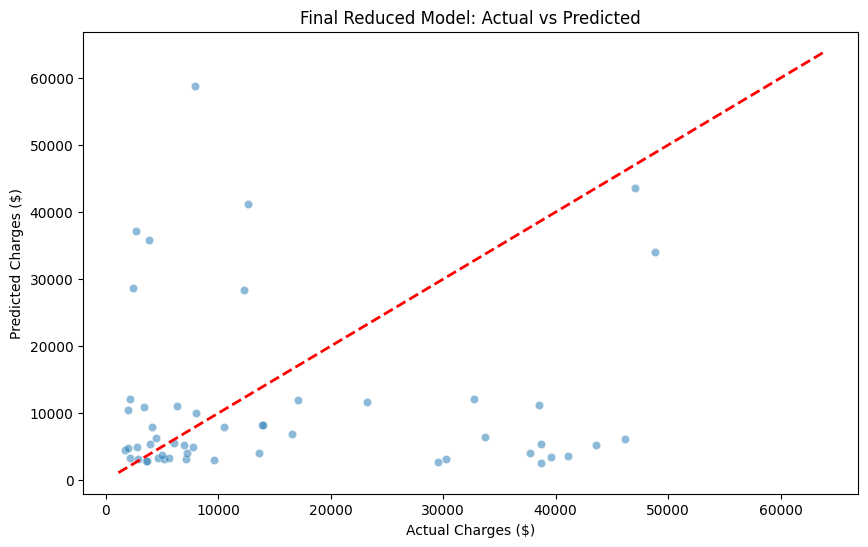

평균 절대 오차 (MAE): $ 13775.70


In [16]:
# 마지막 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm

# 1. 테스트 데이터 준비
X_test_reduced = sm.add_constant(X_test_scaled).drop('region_northwest',axis = 1)

# 2. 예측 수행
y_pred_log = reduced_model.predict(X_test_reduced)

# 3. 로그 역변환 
y_pred_actual = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

# 4. 시각화 
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test_actual,y=y_pred_actual,alpha =0.5)

# 기준선
plt.plot ([y_test_actual.min(),y_test_actual.max()],[y_test_actual.min(),y_test_actual.max()],color = 'red', lw= 2, linestyle='--')
plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.title('Final Reduced Model: Actual vs Predicted')
plt.show()

#5. 최종오차
residuals = y_test_actual - y_pred_actual
print(f"평균 절대 오차 (MAE): ${np.mean(np.abs(residuals)): .2f}")
